# EVALUACIÓN: robustez multi-seed de las mejores configuraciones (top-10 por arquitectura)

Este notebook implementa el **pipeline final de evaluación** para comprobar si las mejores configuraciones encontradas durante V1–V5 se comportan de forma **estable** cuando se repite el entrenamiento bajo **múltiples semillas** (variando la partición train/test y la estocasticidad asociada al entrenamiento). El objetivo no es “volver a buscar hiperparámetros”, sino **validar robustez**: evitar conclusiones basadas en un único split afortunado.

El flujo completo es:

1. **Construcción de presets (top-10)**: para cada arquitectura (MLP, LSTM, TCN y Transformer) se recopilan todos los resultados previos (CSV de fases V1–V5) y se seleccionan las **10 configuraciones con mejor `best_f1`** (F1 macro), evitando duplicados.
2. **Entrenamiento multi-seed**: cada una de esas 10 configuraciones se re-entrena y evalúa usando **10 semillas distintas**, con un split **90% train / 10% test**.
3. **Agregación de métricas**: para cada preset se resume el rendimiento con **media, desviación estándar, mínimo y máximo** de F1 macro entre semillas.
4. **Selección de finalistas**: se elige el “mejor preset” por arquitectura con el criterio:
   - maximizar `f1_mean` (media),
   - desempatar minimizando `f1_std` (variabilidad),
   - si persiste, maximizar `f1_min` (peor caso).
5. **Carga de checkpoints y análisis**: se localizan los `.pth` correspondientes y se generan gráficas (matriz de confusión, ROC/AUC y Precision–Recall/AP) para interpretar los errores.

**Salidas típicas del notebook**
- CSVs de presets: `presets/{ARCH}_top10_global.csv`
- Resultados por seed: `results/**/multiseed_*_runs.csv`
- Resúmenes por preset: `results/**/multiseed_*_summary.csv`
- Tabla LaTeX final con ganadores por arquitectura
- Gráficas para el capítulo de Resultados (matriz de confusión, ROC y PR)


## 1) Selección de las 10 mejores configuraciones por arquitectura (presets)

En este bloque se construyen automáticamente los **presets top-10** para cada arquitectura a partir de los CSV de resultados generados en las fases anteriores (V1–V5). La idea es:

- reunir todas las ejecuciones históricas de una arquitectura,
- ordenar por `best_f1` (F1 macro),
- **eliminar duplicados de configuración** para no quedarnos con muchas filas casi idénticas,
- conservar en cada preset el `target_embedding` con el que esa configuración obtuvo su mejor rendimiento.

El resultado se guarda como un CSV por arquitectura en la carpeta `presets/`. Estos ficheros serán la entrada del entrenamiento multi-seed de la sección siguiente.


In [4]:
import os
import glob
import pandas as pd

TOPK = 10

CONFIG_COLS = {
    "MLP": [
        "hidden_layers","norm_layers","dropout_layers","dropout_rate","activation",
        "base_dim","batch_size","num_layers","pooling","norm","optimizer",
        "momentum_sgd","learning_rate","weight_decay","use_pca","pca_frac"
    ],
    "LSTM": [
        "num_layers","layer_sizes","bidirectional","dropout","dropout_layers","norm_layers",
        "pooling","fc_hidden","activation","norm_post_lstm","native_mode",
        "batch_size","optimizer","momentum_sgd","learning_rate","weight_decay","norm"
    ],
    "TCN": [
        "channels","dilations","kernel_size","convs_per_block","activation",
        "use_weight_norm","wn_on_skip","ln_block_end","pooling","fc_hidden",
        "dropout","batch_size","optimizer","momentum_sgd","learning_rate","weight_decay","norm"
    ],
    "Transformer": [
        "model_dims","num_heads","num_layers","dim_feedforward","dropout","activation",
        "norm_type","pos_encoding","pooling","use_cls_token",
        "lr","learning_rate","weight_decay","batch_size","optimizer","momentum_sgd","norm"
    ],

}

def _best_f1_col(df: pd.DataFrame) -> str:
    # soporta best_f1 / best_F1 / etc.
    for c in df.columns:
        if c.lower() == "best_f1":
            return c
    raise ValueError("No encuentro columna 'best_f1' en el CSV.")

def build_topk_global_configs(model: str, results_glob: str, out_csv: str, topk: int = 5):
    files = sorted(glob.glob(results_glob))
    if not files:
        raise FileNotFoundError(f"No hay archivos con patrón: {results_glob}")

    dfs = []
    for f in files:
        base = os.path.basename(f).lower()
        # evita volver a meter presets/top ya generados
        if base.startswith(("top", "preset", "best_config")):
            continue
        try:
            d = pd.read_csv(f, low_memory=False)
            d["__source_file__"] = os.path.basename(f)
            dfs.append(d)
        except Exception as e:
            print(f"⚠️ Skip {f}: {e}")

    if not dfs:
        raise RuntimeError(f"No se pudo leer ningún CSV válido para {model}.")

    df = pd.concat(dfs, ignore_index=True, sort=False)

    f1c = _best_f1_col(df)
    df[f1c] = pd.to_numeric(df[f1c], errors="coerce")
    df = df.dropna(subset=[f1c]).sort_values(f1c, ascending=False)

    # columnas de config presentes realmente
    cfg_cols = [c for c in CONFIG_COLS[model] if c in df.columns]
    if not cfg_cols:
        raise ValueError(f"No encuentro columnas de config para {model} en tus resultados.")

    # Si existe target_embedding, lo guardamos para entrenar SOLO en el embedding "ganador"
    extra_cols = [c for c in ["target_embedding", "source_params", "best_f1_per_class"] if c in df.columns]

    # DEDUP por hiperparámetros (ignorando target_embedding)
    dedup_subset = [c for c in cfg_cols if c not in ("target_embedding",)]
    keep_cols = cfg_cols + extra_cols + [f1c, "__source_file__"]

    df2 = df[keep_cols].copy()
    df2 = df2.drop_duplicates(subset=dedup_subset, keep="first").head(topk)
    df2 = df2.rename(columns={f1c: "best_f1"})

    os.makedirs(os.path.dirname(out_csv), exist_ok=True)
    df2.to_csv(out_csv, index=False)
    print(f"✅ {model}: {out_csv} (top{topk} global)")

    return df2

# --- Ejecución: genera 4 presets TOP5 globales (uno por arquitectura) ---
build_topk_global_configs("MLP",        "results/MLP/mlp_results*.csv",        f"presets_configs/MLP/top{TOPK}_global.csv",        TOPK)
build_topk_global_configs("LSTM",       "results/LSTM/lstm_results*.csv",       f"presets_configs/LSTM/top{TOPK}_global.csv",       TOPK)
build_topk_global_configs("TCN",        "results/TCN/tcn_results*.csv",        f"presets_configs/TCN/top{TOPK}_global.csv",        TOPK)
build_topk_global_configs("Transformer","results/Transformer/transformer_results*.csv",f"presets_configs/Transformer/top{TOPK}_global.csv",TOPK)


✅ MLP: presets_configs/MLP/top10_global.csv (top10 global)
✅ LSTM: presets_configs/LSTM/top10_global.csv (top10 global)
✅ TCN: presets_configs/TCN/top10_global.csv (top10 global)
✅ Transformer: presets_configs/Transformer/top10_global.csv (top10 global)


,model_dims,num_heads,num_layers,dim_feedforward,dropout,activation,norm_type,pos_encoding,pooling,use_cls_token,...,weight_decay,batch_size,optimizer,momentum_sgd,norm,target_embedding,source_params,best_f1_per_class,best_f1,__source_file__
2191,[256],8,1,512,0.00,leakyrelu,postnorm,learned,max,False,...,0.000001,96,Adam,0.0,NaN,gaitpart_16steps_concat.csv,Preset_11,"[0.68421, 0.61538, 0.75676]",0.68545,transformer_results_v4_concat.csv
436,"[512, 512, 512]",8,3,1024,0.10,mish,prenorm,learned,cls,True,...,0.000005,48,AdamW,0.0,NaN,gaitpart_OUMVLP.csv,Preset_21,"[0.65, 0.76923, 0.62857]",0.68260,transformer_results_v2.csv
391,"[256, 384, 512]",16,3,768,0.10,gelu,prenorm,learned,cls,True,...,0.000001,80,AdamW,0.0,L2,baseline_OUMVLP.csv,Preset_18,"[0.7234, 0.6, 0.70968]",0.67769,transformer_results_v2.csv
2426,"[512, 768, 512]",16,3,896,0.10,gelu,prenorm,learned,cls,True,...,0.000010,40,AdamW,0.0,NaN,gaitpart_16steps_mean.csv,Preset_5,"[0.78431, 0.5, 0.72]",0.66810,transformer_results_v4_mean.csv
2543,[256],8,1,512,0.10,mish,postnorm,learned,max,False,...,0.000001,96,Adam,0.0,NaN,gln_93steps_mean.csv,Preset_13,"[0.68293, 0.61538, 0.70588]",0.66806,transformer_results_v4_mean.csv
2601,"[768, 768]",16,2,1536,0.10,gelu,prenorm,learned,max,False,...,0.000001,32,AdamW,0.0,minmax,gaitpart_16steps_mean.csv,Preset_3,"[0.71429, 0.54545, 0.74286]",0.66753,transformer_results_v4_mean.csv
319,"[320, 480, 640]",8,3,960,0.15,gelu,prenorm,learned,mean,False,...,0.000001,48,AdamW,0.0,NaN,gaitpart_OUMVLP.csv,Preset_12,"[0.69767, 0.61538, 0.6875]",0.66685,transformer_results_v2.csv
3301,"[512, 640, 768, 640]",16,4,1280,0.10,silu,postnorm,sinusoidal,cls,True,...,0.000001,32,Adam,0.0,NaN,gaitpart_OUMVLP_TOP30.csv,Preset_11,"[0.73684, 0.54545, 0.71795]",0.66675,transformer_results_v5_top30%.csv
3353,"[160, 320, 640]",10,3,1024,0.25,gelu,postnorm,sinusoidal,mean,False,...,0.000001,32,AdamW,0.0,NaN,gaitpart_OUMVLP_TOP30.csv,Preset_15,"[0.79167, 0.625, 0.58333]",0.66667,transformer_results_v5_top30%.csv
2586,"[256, 384, 512, 640]",16,4,1536,0.00,gelu,prenorm,learned,mean,False,...,0.000001,32,AdamW,0.0,NaN,gaitpart_16steps_mean.csv,Preset_22,"[0.77273, 0.5, 0.71429]",0.66234,transformer_results_v4_mean.csv


## 2) Localización de embeddings (índice de rutas)

Los resultados históricos almacenan el embedding mediante su nombre (`target_embedding`), pero en el proyecto los CSV de embeddings pueden estar repartidos en varias carpetas. Para que el pipeline sea robusto, aquí se crea un **índice nombre → ruta**:

- se recorren varias carpetas candidatas de embeddings,
- se construye un diccionario con la ruta real de cada CSV,
- y luego se resuelve cada `target_embedding` de un preset a su fichero físico correspondiente.

Con esto, el resto del notebook puede trabajar “por nombre” sin depender de rutas hardcodeadas para cada caso.


In [5]:
# HELPERS RUTAS / ÍNDICE
from pathlib import Path


def build_embedding_index(project_root: Path, data_roots: list[str]) -> dict[str, Path]:
    """
    Crea un índice: { 'archivo.csv' -> Path absoluto } buscando recursivamente en DATA_ROOTS.
    Asume que NO hay nombres repetidos (tu caso).
    """
    index = {}
    for root in data_roots:
        base = project_root / root
        if not base.exists():
            continue
        for p in base.rglob("*.csv"):
            index[p.name] = p.resolve()
    return index


def resolve_embedding_path(embedding_ref: str, project_root: Path, emb_index: dict[str, Path]) -> Path:
    """
    embedding_ref puede ser:
      - 'baseline_CASIAB.csv' (nombre)
      - 'Gait_Embeddings_good/baseline_CASIAB.csv' (relpath)
    Devuelve Path ABSOLUTO.
    """
    if embedding_ref is None:
        raise ValueError("embedding_ref es None")

    s = str(embedding_ref).strip().replace("\\", "/")

    # 1) Si parece ruta relativa y existe
    p_rel = (project_root / s)
    if p_rel.exists():
        return p_rel.resolve()

    # 2) Si es un nombre de archivo (sin carpetas), usar índice
    name = Path(s).name
    if name in emb_index:
        return emb_index[name]

    # 3) Último intento: buscar por sufijo dentro del índice (por si te llega con subcarpetas raras)
    matches = [p for k, p in emb_index.items() if str(p).replace("\\", "/").endswith(s)]
    if len(matches) == 1:
        return matches[0]

    raise FileNotFoundError(f"No pude resolver el embedding '{embedding_ref}'.")


## 3) Entrenamiento multi-seed (10 presets × 10 semillas)

Esta es la parte central del notebook. Para cada arquitectura:

- se lee su CSV `presets/{ARCH}_top10_global.csv`,
- se re-entrenan **las 10 configuraciones** seleccionadas,
- y cada configuración se ejecuta bajo **10 semillas distintas**.

En cada semilla se realiza un split **90% train / 10% test** (manteniendo el particionado por `video_ID` para evitar fugas), y se entrena el modelo desde cero. El objetivo es estimar:

- el rendimiento típico (media de F1 macro),
- la variabilidad (desviación estándar),
- y el peor/mejor caso (mínimo y máximo).

**Por qué 90/10 y no holdout intocable en esta fase**  
Con 432 vídeos y una clase minoritaria pequeña (centro), reservar un conjunto “intocable” reduce aún más ejemplos de entrenamiento y deja muy pocas muestras en evaluación para algunas clases, aumentando la varianza. Por eso aquí se prioriza robustez por repetición multi-seed.

**Notas de implementación**
- El notebook convierte cada fila del preset a un diccionario `cfg` mediante funciones específicas (`cfg_from_row_*`), porque cada arquitectura tiene hiperparámetros distintos.
- Para cada run se guardan métricas por seed en un CSV “runs” y un resumen agregado en un CSV “summary”.
- En la celda final del bloque se elige qué arquitecturas ejecutar (por defecto puede haber una lista parcial; basta con añadir las que falten para lanzarlas también).


In [ ]:

import os
import ast
import json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from pathlib import Path 

from src.utils.save_methods import save_model
from src.mlp.prepare_data import prepare_mlp_data
from src.mlp.train import run_training_mlp
from src.mlp.model import FlexibleMLP

from src.lstm.prepare_data import prepare_lstm_data, collate_sequences
from src.lstm.train import run_training_lstm
from src.lstm.model import FlexibleLSTM

from src.tcn.prepare_data import prepare_tcn_data, collate_sequences
from src.tcn.train import run_training_tcn
from src.tcn.model import FlexibleTCN

from src.transformer.prepare_data import prepare_transformer_data, collate_transformer
from src.transformer.train import run_training_transformer
from src.transformer.model import FlexibleTransformer


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------- CONFIG --------
BASE_DIR = "."  # raíz del proyecto (relativa)

DATA_ROOTS = [
    "Gait_Embeddings_good",
    "Gait_Embeddings_Combined",
    "Gait_Embeddings_TopSteps",
    "Gait_Embeddings_WorstSteps",
]

# tu helper (si internamente usa Path, le pasamos Path(BASE_DIR) sin usar "/")
EMB_INDEX = build_embedding_index(Path(BASE_DIR), DATA_ROOTS)

TEST_SIZE = 0.10
SPLIT_SEEDS = [8, 24, 33, 888, 800, 123, 111, 425, 672, 69]

TOPK = 10
EPOCHS = 5000

PRESETS = {
    "MLP": f"presets_configs/MLP/top{TOPK}_global.csv",
    "LSTM": f"presets_configs/LSTM/top{TOPK}_global.csv",
    "TCN": f"presets_configs/TCN/top{TOPK}_global.csv",
    "Transformer": f"presets_configs/Transformer/top{TOPK}_global.csv",
}

OUT_DIR = "results/Final_evaluation"
os.makedirs(OUT_DIR, exist_ok=True)

# (Opcional) Guardado de modelos si el resultado es MUY bueno
SAVE_MODELS = True
THRESHOLD_F1 = 0.50  # umbral alto
SAVE_DIR = {
    "MLP": "saved_models/Final_evaluation/MLP",
    "LSTM": "saved_models/Final_evaluation/LSTM",
    "TCN": "saved_models/Final_evaluation/TCN",
    "Transformer": "saved_models/Final_evaluation/Transformer",
}
for d in SAVE_DIR.values():
    os.makedirs(d, exist_ok=True)

USE_CLASS_WEIGHTS = True
CLASS_WEIGHTS = None
LABEL_SMOOTH = 0.02
CLIP_NORM = 1.0

# -------- parsing utils --------
def L(x, default=None):
    if default is None:
        default = []
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return default
    s = str(x).strip()
    if s == "" or s.lower() in ("none", "nan"):
        return default
    try:
        v = ast.literal_eval(s)
        return v if isinstance(v, list) else default
    except:
        return default

def B(x, default=False):
    if isinstance(x, bool):
        return x
    if pd.isna(x):
        return default
    s = str(x).strip().lower()
    if s in ("true", "1", "yes", "y"):
        return True
    if s in ("false", "0", "no", "n"):
        return False
    try:
        return bool(ast.literal_eval(str(x)))
    except:
        return default


# CFG builders 
def cfg_from_row_mlp(row):
    return {
        "pooling": str(row["pooling"]).strip(),
        "norm": str(row["norm"]).strip(),
        "use_pca": B(row["use_pca"]),
        "pca_frac": None if pd.isna(row.get("pca_frac", None)) else float(row["pca_frac"]),
        "hidden_layers": L(row["hidden_layers"], []),
        "norm_layers": L(row["norm_layers"], []),
        "dropout_layers": L(row["dropout_layers"], []),
        "dropout_rate": float(row["dropout_rate"]),
        "activation": str(row["activation"]).strip(),
        "batch_size": int(row["batch_size"]),
        "optimizer": str(row["optimizer"]).strip(),
        "learning_rate": float(row["learning_rate"]),
        "weight_decay": float(row.get("weight_decay", 0.0)),
        "momentum_sgd": None if pd.isna(row.get("momentum_sgd", np.nan)) else float(row["momentum_sgd"]),
        "epochs": EPOCHS,
    }

def cfg_from_row_lstm(row):
    return {
        "norm": str(row["norm"]).strip(),
        "num_layers": int(row["num_layers"]),
        "layer_sizes": L(row["layer_sizes"], []),
        "bidirectional": B(row["bidirectional"]),
        "dropout": float(row["dropout"]),
        "dropout_layers": L(row["dropout_layers"], []),
        "norm_layers": L(row["norm_layers"], []),
        "pooling": str(row["pooling"]).strip(),
        "fc_hidden": None if pd.isna(row.get("fc_hidden", None)) else int(row["fc_hidden"]),
        "activation": str(row["activation"]).strip(),
        "norm_post_lstm": B(row["norm_post_lstm"]),
        "native_mode": B(row["native_mode"]),
        "batch_size": int(row["batch_size"]),
        "optimizer": str(row["optimizer"]).strip(),
        "learning_rate": float(row["learning_rate"]),
        "weight_decay": float(row.get("weight_decay", 0.0)),
        "momentum_sgd": None if pd.isna(row.get("momentum_sgd", np.nan)) else float(row["momentum_sgd"]),
        "epochs": EPOCHS,
    }

def cfg_from_row_tcn(row):
    d = row.get("dropout", 0.0)
    if isinstance(d, str) and d.strip().startswith("["):
        try:
            d = ast.literal_eval(d)
        except:
            d = 0.0
    else:
        d = float(d)

    lnbe = row.get("ln_block_end", False)
    if isinstance(lnbe, str) and lnbe.strip().startswith("["):
        lnbe = [B(x) for x in ast.literal_eval(lnbe)]
    else:
        lnbe = B(lnbe)

    dil = row.get("dilations", None)
    dil = None if pd.isna(dil) else L(dil, [])

    lr = float(row["learning_rate"]) if "learning_rate" in row else float(row["lr"])

    return {
        "norm": str(row["norm"]).strip(),
        "channels": L(row["channels"], []),
        "dilations": dil,
        "kernel_size": int(row["kernel_size"]),
        "convs_per_block": int(row["convs_per_block"]),
        "activation": str(row["activation"]).strip(),
        "dropout": d,
        "use_weight_norm": B(row.get("use_weight_norm", False)),
        "wn_on_skip": B(row.get("wn_on_skip", False)),
        "ln_block_end": lnbe,
        "pooling": str(row["pooling"]).strip(),
        "fc_hidden": None if pd.isna(row.get("fc_hidden", None)) else int(row["fc_hidden"]),
        "batch_size": int(row["batch_size"]),
        "optimizer": str(row["optimizer"]).strip(),
        "learning_rate": lr,
        "weight_decay": float(row.get("weight_decay", 0.0)),
        "momentum_sgd": None if pd.isna(row.get("momentum_sgd", np.nan)) else float(row["momentum_sgd"]),
        "epochs": EPOCHS,
    }

def cfg_from_row_transformer(row):
    model_dims = L(row["model_dims"], [])
    num_layers = int(row["num_layers"])
    if model_dims and len(model_dims) != num_layers:
        raise ValueError("len(model_dims) != num_layers")

    pooling = str(row["pooling"]).strip()
    use_cls = (pooling.lower() == "cls") if "use_cls_token" not in row else B(row["use_cls_token"])
    lr = float(row["lr"]) if "lr" in row and not pd.isna(row["lr"]) else float(row["learning_rate"])

    return {
        "norm": str(row.get("norm", "L2")).strip(),
        "model_dims": model_dims,
        "num_heads": int(row["num_heads"]),
        "num_layers": num_layers,
        "dim_feedforward": int(row["dim_feedforward"]),
        "dropout": float(row["dropout"]),
        "activation": str(row["activation"]).strip(),
        "norm_type": str(row["norm_type"]).strip(),
        "pos_encoding": str(row["pos_encoding"]).strip(),
        "pooling": pooling,
        "use_cls_token": use_cls,
        "batch_size": int(row["batch_size"]),
        "optimizer": str(row["optimizer"]).strip(),
        "learning_rate": lr,
        "weight_decay": float(row.get("weight_decay", 0.0)),
        "momentum_sgd": None if pd.isna(row.get("momentum_sgd", np.nan)) else float(row["momentum_sgd"]),
        "epochs": EPOCHS,
    }

CFG_FROM_ROW = {
    "MLP": cfg_from_row_mlp,
    "LSTM": cfg_from_row_lstm,
    "TCN": cfg_from_row_tcn,
    "Transformer": cfg_from_row_transformer,
}


def train_eval_one(arch: str, df_emb: pd.DataFrame, cfg: dict, split_seed: int):
    """
    Devuelve: best_f1, best_epoch, best_f1_per_class, history, best_state, model
    (history/best_state/model se usan si quieres guardar).
    """
    if arch == "MLP":
        tr_ds, te_ds, tr_ids, te_ids = prepare_mlp_data(
            df_emb,
            pooling=cfg["pooling"],
            norm=cfg["norm"],
            test_size=TEST_SIZE,
            use_pca=cfg["use_pca"],
            pca_frac=cfg.get("pca_frac", None),
            seed=split_seed,
            return_preproc=False
        )
        tr_loader = DataLoader(tr_ds, batch_size=cfg["batch_size"], shuffle=True)
        te_loader = DataLoader(te_ds, batch_size=cfg["batch_size"], shuffle=False)

        input_dim = tr_ds[0][0].shape[0]
        model = FlexibleMLP(
            input_dim=input_dim,
            hidden_layers=cfg["hidden_layers"],
            activation=cfg["activation"],
            dropout=cfg["dropout_rate"],
            normalization_layers=cfg["norm_layers"],
            dropout_layers=cfg["dropout_layers"],
            num_classes=3
        ).to(DEVICE)

        history, best_state = run_training_mlp(
            model, tr_loader, te_loader,
            epochs=cfg["epochs"],
            lr=cfg["learning_rate"],
            weight_decay=cfg["weight_decay"],
            optimizer_name=cfg["optimizer"],
            momentum_sgd=(cfg["momentum_sgd"] if str(cfg["optimizer"]).upper() == "SGD" else None),
            use_class_weights=USE_CLASS_WEIGHTS,
            class_weights=CLASS_WEIGHTS,
            label_smoothing=LABEL_SMOOTH,
            clip_grad_norm=CLIP_NORM
        )

    elif arch == "LSTM":
        tr_list, te_list, tr_ids, te_ids = prepare_lstm_data(
            df_emb, norm=cfg["norm"], test_size=TEST_SIZE, seed=split_seed, return_preproc=False
        )
        tr_loader = DataLoader(tr_list, batch_size=cfg["batch_size"], shuffle=True, collate_fn=collate_sequences)
        te_loader = DataLoader(te_list, batch_size=cfg["batch_size"], shuffle=False, collate_fn=collate_sequences)

        input_dim = int(df_emb.filter(like="feat_").shape[1])
        model = FlexibleLSTM(
            input_dim=input_dim,
            num_layers=cfg["num_layers"],
            layer_sizes=cfg["layer_sizes"],
            bidirectional=cfg["bidirectional"],
            dropout=cfg["dropout"],
            dropout_layers=cfg["dropout_layers"],
            norm_layers=cfg["norm_layers"],
            pooling=cfg["pooling"],
            fc_hidden=cfg["fc_hidden"],
            activation=cfg["activation"],
            norm_post_lstm=cfg["norm_post_lstm"],
            native_mode=cfg["native_mode"],
            num_classes=3
        ).to(DEVICE)

        history, best_state = run_training_lstm(
            model, tr_loader, te_loader,
            epochs=cfg["epochs"],
            lr=cfg["learning_rate"],
            weight_decay=cfg["weight_decay"],
            optimizer_name=cfg["optimizer"],
            momentum_sgd=(cfg["momentum_sgd"] if str(cfg["optimizer"]).upper() == "SGD" else None),
            use_class_weights=USE_CLASS_WEIGHTS,
            class_weights=CLASS_WEIGHTS,
            label_smoothing=LABEL_SMOOTH,
            clip_grad_norm=CLIP_NORM
        )

    elif arch == "TCN":
        tr_list, te_list, tr_ids, te_ids = prepare_tcn_data(
            df_emb, norm=cfg["norm"], test_size=TEST_SIZE, seed=split_seed, return_preproc=False
        )
        tr_loader = DataLoader(tr_list, batch_size=cfg["batch_size"], shuffle=True, collate_fn=collate_sequences)
        te_loader = DataLoader(te_list, batch_size=cfg["batch_size"], shuffle=False, collate_fn=collate_sequences)

        input_dim = int(df_emb.filter(like="feat_").shape[1])
        model = FlexibleTCN(
            input_dim=input_dim,
            channels=cfg["channels"],
            kernel_size=cfg["kernel_size"],
            dilations=cfg["dilations"],
            convs_per_block=cfg["convs_per_block"],
            dropout=cfg["dropout"],
            activation=cfg["activation"],
            use_weight_norm=cfg["use_weight_norm"],
            wn_on_skip=cfg["wn_on_skip"],
            ln_block_end=cfg["ln_block_end"],
            pooling=cfg["pooling"],
            fc_hidden=cfg["fc_hidden"],
            num_classes=3
        ).to(DEVICE)

        history, best_state = run_training_tcn(
            model, tr_loader, te_loader,
            epochs=cfg["epochs"],
            lr=cfg["learning_rate"],
            weight_decay=cfg["weight_decay"],
            optimizer_name=cfg["optimizer"],
            momentum_sgd=(cfg["momentum_sgd"] if str(cfg["optimizer"]).upper() == "SGD" else None),
            use_class_weights=USE_CLASS_WEIGHTS,
            class_weights=CLASS_WEIGHTS,
            label_smoothing=LABEL_SMOOTH,
            clip_grad_norm=CLIP_NORM
        )

    else:  # Transformer
        tr_list, te_list, tr_ids, te_ids = prepare_transformer_data(
            df_emb, norm=cfg["norm"], test_size=TEST_SIZE, seed=split_seed, return_preproc=False
        )
        tr_loader = DataLoader(tr_list, batch_size=cfg["batch_size"], shuffle=True, collate_fn=collate_transformer)
        te_loader = DataLoader(te_list, batch_size=cfg["batch_size"], shuffle=False, collate_fn=collate_transformer)

        input_dim = int(df_emb.filter(like="feat_").shape[1])
        max_seq_len = max(len(s[0]) for s in tr_list) if len(tr_list) > 0 else 128

        model = FlexibleTransformer(
            input_dim=input_dim,
            model_dim=cfg["model_dims"],
            num_heads=cfg["num_heads"],
            num_layers=cfg["num_layers"],
            dim_feedforward=cfg["dim_feedforward"],
            dropout=cfg["dropout"],
            activation=cfg["activation"],
            norm_type=cfg["norm_type"],
            pos_encoding=cfg["pos_encoding"],
            use_cls_token=cfg["use_cls_token"],
            pooling=cfg["pooling"],
            num_classes=3,
            max_seq_len=max_seq_len
        ).to(DEVICE)

        history, best_state = run_training_transformer(
            model=model,
            train_loader=tr_loader,
            test_loader=te_loader,
            epochs=cfg["epochs"],
            lr=cfg["learning_rate"],
            weight_decay=cfg["weight_decay"],
            optimizer_name=cfg["optimizer"],
            momentum_sgd=(cfg["momentum_sgd"] if str(cfg["optimizer"]).upper() == "SGD" else None),
            use_class_weights=USE_CLASS_WEIGHTS,
            class_weights=CLASS_WEIGHTS,
            label_smoothing=LABEL_SMOOTH,
            clip_grad_norm=CLIP_NORM
        )

    best_f1 = float(history.get("best_f1", np.nan))
    best_epoch = int(history.get("best_epoch", -1))
    best_f1_per_class = history.get("best_f1_per_class", None)
    return best_f1, best_epoch, best_f1_per_class, history, best_state, model


def run_robustness_from_presets(arch: str):
    presets_path = PRESETS[arch]
    df_presets = pd.read_csv(presets_path, low_memory=False).copy()

    if "best_f1" in df_presets.columns:
        df_presets["best_f1"] = pd.to_numeric(df_presets["best_f1"], errors="coerce")
        df_presets = df_presets.sort_values("best_f1", ascending=False)

    df_presets = df_presets.head(TOPK).copy()

    # cache para no releer el mismo embedding N veces
    df_cache = {}

    rows = []
    run_id = 0

    print(f"\n=== {arch} | TOPK={TOPK} | seeds={len(SPLIT_SEEDS)} ===")
    for rank, (_, prow) in enumerate(df_presets.iterrows(), start=1):
        cfg = CFG_FROM_ROW[arch](prow)
        source_params = str(prow.get("source_params", f"TOP{rank}"))

        # coger embedding del preset
        emb_ref = prow.get("embedding_relpath", None)
        if emb_ref is None or (isinstance(emb_ref, float) and np.isnan(emb_ref)) or str(emb_ref).strip() == "":
            emb_ref = prow["target_embedding"]

        emb_abs_path = resolve_embedding_path(str(emb_ref), Path(BASE_DIR), EMB_INDEX)
        emb_abs = str(emb_abs_path)
        emb_rel = os.path.relpath(emb_abs, start=BASE_DIR).replace("\\", "/")
        emb_name = os.path.basename(emb_abs)
        emb_stem = os.path.splitext(emb_name)[0]

        if emb_abs not in df_cache:
            df_cache[emb_abs] = pd.read_csv(emb_abs, low_memory=False)
        df_emb = df_cache[emb_abs]

        print(f"\nPreset {rank}/{TOPK} | {source_params} | emb={emb_name}")

        for split_seed in SPLIT_SEEDS:
            run_id += 1
            best_f1, best_epoch, best_f1_per_class, history, best_state, model = train_eval_one(
                arch=arch,
                df_emb=df_emb,
                cfg=cfg,
                split_seed=split_seed
            )

            model_path = ""
            if SAVE_MODELS and history["best_f1"] >= THRESHOLD_F1:
                model.load_state_dict(best_state)

                # ---- nombre corto: <arch>_<run_id>_<embedding>_seed<seed>.pth ----
                # emb_stem YA lo tienes arriba como: emb_stem = os.path.splitext(emb_name)[0]
                # limpieza ligera por si acaso (espacios raros)
                emb_stem_clean = emb_stem.replace(" ", "_")

                model_path = os.path.join(
                    SAVE_DIR[arch],
                    f"{arch.lower()}{run_id}_{emb_stem_clean}_seed{split_seed}.pth"
                )

                config_to_save = dict(cfg)
                config_to_save.update({
                    "arch": arch,
                    "target_embedding": emb_name,
                    "embedding_relpath": emb_rel,
                    "split_seed": int(split_seed),
                    "run_id": int(run_id),
                    "preset_rank": int(rank),
                    "source_params": source_params,
                })
                save_model(model, model_path, config_to_save, run_id)


            rows.append({
                "run_id": run_id,
                "arch": arch,
                "preset_rank": rank,
                "source_params": source_params,
                "target_embedding": emb_name,
                "embedding_relpath": emb_rel,
                "split_seed": int(split_seed),
                "best_val_f1": best_f1,
                "best_epoch": best_epoch,
                "best_f1_per_class": json.dumps(best_f1_per_class) if best_f1_per_class is not None else "",
                "model_path": model_path,
                "cfg_json": json.dumps(cfg, default=str),
            })

    df_runs = pd.DataFrame(rows)

    summary = (
        df_runs.groupby(["arch", "target_embedding", "embedding_relpath", "preset_rank", "source_params", "cfg_json"], as_index=False)
        .agg(
            f1_mean=("best_val_f1", "mean"),
            f1_std=("best_val_f1", "std"),
            f1_min=("best_val_f1", "min"),
            f1_max=("best_val_f1", "max"),
            n_seeds=("best_val_f1", "count"),
        )
        .sort_values(["f1_mean", "f1_std"], ascending=[False, True])
    )

    out_runs = os.path.join(OUT_DIR, f"{arch}_evaluation.csv")
    out_sum  = os.path.join(OUT_DIR, f"{arch}_summary.csv")
    
    # redondear best_val_f1
    summary["best_val_f1"] = summary["best_val_f1"].round(4)
    summary["best_f1_per_class"] = summary["best_f1_per_class"].apply(lambda x: ([round(v, 4) for v in json.loads(x)]))

    # redondear f1_mean/std
    summary["f1_mean"] = summary["f1_mean"].round(4)
    summary["f1_std"] = summary["f1_std"].round(4)
    summary["f1_min"] = summary["f1_min"].round(4)
    summary["f1_max"] = summary["f1_max"].round(4)

    df_runs.to_csv(out_runs, index=False)
    summary.to_csv(out_sum, index=False)

    print(f"\n✅ Guardado runs    -> {out_runs}")
    print(f"✅ Guardado summary -> {out_sum}")

    try:
        from IPython.display import display
        display(summary.head(10))
    except:
        pass

    return df_runs, summary



for arch in ["MLP", "LSTM", "TCN", "Transformer"]:
    run_robustness_from_presets(arch)


## 4) Carga automática de checkpoints para los finalistas

Una vez generados los CSV de resumen (`*summary*.csv`), el siguiente paso es recuperar los **checkpoints `.pth`** correspondientes a las mejores configuraciones, para poder hacer análisis cualitativo con gráficas.

En lugar de asumir nombres fijos de ficheros, este bloque busca de forma automática:

- el preset ganador (según `f1_mean`, `f1_std`, `f1_min`),
- la configuración serializada (`cfg_json`),
- y el `.pth` guardado cuya `config` coincide con esos hiperparámetros y embedding.

Esto permite regenerar modelos y seguir localizándolos aunque cambie el naming interno de los ficheros.


In [ ]:
import os
import json
import math
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import torch



SUMMARY_DIR = "results/Final_evaluation"

# dónde buscar .pth
SEARCH_MODEL_DIRS = ["saved_models/Final_evaluation"]

ARCHS = ["MLP", "LSTM", "TCN", "Transformer"]



# Elegir config ganadora desde el summary
def pick_winner_row(summary_csv: str) -> pd.Series:
    df = pd.read_csv(summary_csv, low_memory=False).copy()
    for c in ["f1_mean", "f1_std", "f1_min", "f1_max"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # criterio: max f1_mean, min f1_std, max f1_min
    df = df.dropna(subset=["f1_mean"]).copy()
    df = df.sort_values(["f1_mean", "f1_std", "f1_min"], ascending=[False, True, False])

    if len(df) == 0:
        raise ValueError(f"Summary vacío o inválido: {summary_csv}")

    return df.iloc[0]



def load_ckpt_config(pth_path: str):
    """
    Devuelve (state_dict, config_dict, raw_obj)
    - state_dict: dict de pesos si existe
    - config_dict: dict de config si existe
    - raw_obj: lo cargado por torch.load
    """
    obj = torch.load(pth_path, map_location="cpu")

    # caso A: guardaste un dict con state_dict/config
    if isinstance(obj, dict):
        # state_dict puede estar en distintas claves
        sd = None
        for k in ["state_dict", "model_state_dict", "model", "net"]:
            if k in obj and isinstance(obj[k], dict):
                sd = obj[k]
                break
        if sd is None:
            # a veces el dict entero ya es el state_dict
            # pero en ese caso sus claves suelen ser pesos tipo "layer.weight"
            # lo tratamos abajo
            pass

        cfg = None
        for k in ["config", "cfg", "config_to_save", "meta", "hparams"]:
            if k in obj:
                cfg = obj[k]
                break

        # si cfg viene como JSON string
        if isinstance(cfg, str):
            try:
                cfg = json.loads(cfg)
            except:
                cfg = None

        # si el dict entero parece state_dict (claves tipo "fc1.weight")
        if sd is None and all(isinstance(k, str) and "." in k for k in obj.keys()):
            sd = obj
            # aquí normalmente NO hay config
            return sd, None, obj

        return sd, cfg if isinstance(cfg, dict) else None, obj

    # caso B: guardaste directamente state_dict
    if isinstance(obj, dict) and all(isinstance(k, str) and "." in k for k in obj.keys()):
        return obj, None, obj

    return None, None, obj



# Matching robusto entre cfg_json (summary) y config guardada
IGNORE_KEYS = {
    "arch", "model", "target_embedding", "embedding_relpath",
    "split_seed", "run_id", "best_f1", "best_val_f1",
    "preset_rank", "source_params", "epochs",
}

def _is_nan(x):
    try:
        return isinstance(x, float) and math.isnan(x)
    except:
        return False

def normalize_value(v):
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, (np.floating,)):
        return float(v)
    if isinstance(v, (list, tuple)):
        return [normalize_value(x) for x in v]
    return v

def values_equal(a, b, tol=1e-9):
    a = normalize_value(a)
    b = normalize_value(b)

    if _is_nan(a) and _is_nan(b):
        return True

    # floats
    if isinstance(a, (float, int)) and isinstance(b, (float, int)):
        return abs(float(a) - float(b)) <= tol

    # lists
    if isinstance(a, list) and isinstance(b, list):
        if len(a) != len(b):
            return False
        return all(values_equal(x, y, tol=tol) for x, y in zip(a, b))

    return a == b

def cfg_match(winner_cfg: dict, ckpt_cfg: dict) -> bool:
    if not isinstance(winner_cfg, dict) or not isinstance(ckpt_cfg, dict):
        return False

    for k, v in winner_cfg.items():
        if k in IGNORE_KEYS:
            continue
        if k not in ckpt_cfg:
            return False
        if not values_equal(v, ckpt_cfg[k]):
            return False

    return True



# Buscar el .pth que matchea para cada arquitectura
def find_all_pths(search_dirs):
    pths = []
    for d in search_dirs:
        if os.path.isdir(d):
            pths.extend(glob(os.path.join(d, "**", "*.pth"), recursive=True))
    return sorted(set(pths))

def resolve_winner_checkpoint_for_arch(arch: str, prefer_seed: int = 42):
    summary_csv = os.path.join(SUMMARY_DIR, f"{arch}_summary.csv")
    if not os.path.isfile(summary_csv):
        raise FileNotFoundError(f"No existe: {summary_csv}")

    winner = pick_winner_row(summary_csv)

    # winner_cfg_json viene como string
    if "cfg_json" not in winner:
        raise ValueError(f"El summary de {arch} no tiene columna cfg_json.")
    winner_cfg = json.loads(winner["cfg_json"])

    # info de embedding para “filtrar” un poco si quieres
    winner_emb = str(winner.get("target_embedding", "")).strip()

    # indexa pths 1 vez
    all_pths = find_all_pths(SEARCH_MODEL_DIRS)

    matches = []
    for pth in all_pths:
        sd, cfg, _ = load_ckpt_config(pth)
        if cfg is None:
            continue

        # opcional: filtrar por arch y embedding si existen en cfg
        cfg_arch = str(cfg.get("arch", cfg.get("model", ""))).strip()
        if cfg_arch and cfg_arch.lower() != arch.lower():
            continue

        cfg_emb = str(cfg.get("target_embedding", "")).strip()
        # si winner_emb es nombre de fichero, comparamos basename
        if winner_emb:
            if Path(cfg_emb).name and Path(winner_emb).name:
                if Path(cfg_emb).name != Path(winner_emb).name:
                    pass

        if cfg_match(winner_cfg, cfg):
            seed = cfg.get("split_seed", None)
            matches.append((pth, seed))

    if not matches:
        return None, winner  # no encontrado
    
    matches_seed = [m for m in matches if m[1] == prefer_seed]
    chosen = matches_seed[0][0] if matches_seed else matches[0][0]
    return chosen, winner




winner_ckpts = {}

for arch in ARCHS:
    ckpt_path, winner_row = resolve_winner_checkpoint_for_arch(arch, prefer_seed=42)

    if ckpt_path is None:
        print(f"[WARN] {arch}: no encontré ningún .pth que matchee la config ganadora del summary.")
        print(f"       Embedding ganador (summary): {winner_row.get('target_embedding', '')}")
        print(f"       Pista: asegúrate de que tus .pth guardan un dict con 'config'.")
        continue

    sd, cfg, raw = load_ckpt_config(ckpt_path)
    print(f"[OK] {arch}: checkpoint ganador encontrado:")
    print(f"     {ckpt_path}")

    winner_ckpts[arch] = {
        "ckpt_path": ckpt_path,
        "state_dict": sd,
        "config": cfg,
        "winner_row": winner_row.to_dict(),
        "raw": raw,  # por si quieres inspeccionar
    }

# winner_ckpts ahora contiene los 4 (si se encontraron)


## 5) Tabla final: mejor configuración por arquitectura (LaTeX)

Aquí se cargan todos los CSV de resumen (`*summary*.csv`) generados por el multi-seed y se selecciona un único “ganador” por arquitectura usando el criterio:

1) maximizar F1 macro medio (`f1_mean`),  
2) desempatar con menor variabilidad (`f1_std`),  
3) si persiste, maximizar el peor caso (`f1_min`).

Con esos ganadores se genera una tabla en formato **LaTeX** lista para pegar en la memoria. Esta tabla resume, por arquitectura:

- embedding ganador,
- ranking del preset,
- F1 medio / desviación / mínimo / máximo,
- número de semillas evaluadas.


In [7]:
import os
import re
import numpy as np
import pandas as pd
from glob import glob

# 1) Encontrar CSVs de summary automáticamente
SUMMARY_ROOT = "results"
INCLUDE_RE = re.compile(r".*summary.*\.csv$", re.IGNORECASE)

csv_paths = []
for p in glob(os.path.join(SUMMARY_ROOT, "**", "*.csv"), recursive=True):
    if INCLUDE_RE.match(os.path.basename(p)):
        csv_paths.append(p)

csv_paths = sorted(csv_paths)
if not csv_paths:
    raise FileNotFoundError(
        "No se encontraron CSVs de summary (patrón: '*summary*.csv'). Ajusta SUMMARY_ROOT/INCLUDE_RE."
    )

print(f"Found {len(csv_paths)} summary CSV files:")
for p in csv_paths:
    print(" -", p)

# ======================================================
# 2) Cargar y normalizar (soporta columnas arch/model)
# ======================================================
dfs = []
for p in csv_paths:
    try:
        df = pd.read_csv(p, low_memory=False)
    except Exception as e:
        print(f"[WARN] Skip {p} (read error): {e}")
        continue

    # Requisitos mínimos
    has_arch = ("arch" in df.columns) or ("model" in df.columns)
    needed_cols = {"preset_rank", "target_embedding", "f1_mean", "f1_std", "f1_min", "f1_max", "n_seeds", "cfg_json"}
    if (not has_arch) or (not needed_cols.issubset(set(df.columns))):
        print(f"[WARN] Skip {p} (missing required columns)")
        continue

    # Normalizar nombre de arquitectura -> "Model"
    df["Model"] = df["arch"].astype(str) if "arch" in df.columns else df["model"].astype(str)

    # Guardar fuente (útil para trazabilidad)
    df["source_csv"] = os.path.basename(p)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Normaliza numéricos
for c in ["preset_rank", "f1_mean", "f1_std", "f1_min", "f1_max", "n_seeds"]:
    df_all[c] = pd.to_numeric(df_all[c], errors="coerce")

df_all = df_all.dropna(subset=[
    "Model", "target_embedding", "preset_rank",
    "f1_mean", "f1_std", "f1_min", "f1_max", "n_seeds",
    "cfg_json"
]).copy()

# ======================================================
# 3) Seleccionar ganadora por arquitectura
#    MISMO criterio que el loader:
#    max f1_mean, desempate min f1_std, desempate max f1_min
# ======================================================
winners = []
for model, g in df_all.groupby("Model", sort=False):
    g = g.sort_values(
        by=["f1_mean", "f1_std", "f1_min"],
        ascending=[False, True, False]
    )
    winners.append(g.iloc[0])

winners = pd.DataFrame(winners)

# Orden deseado
order = ["MLP", "LSTM", "TCN", "Transformer"]
winners["Model"] = pd.Categorical(winners["Model"], categories=order, ordered=True)
winners = winners.sort_values("Model").reset_index(drop=True)

# ======================================================
# 4) LaTeX (caption en español, columnas en inglés)
# ======================================================
def esc_tex(x: str) -> str:
    return str(x).replace("_", r"\_")

def fmt(x, nd=3):
    try:
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

USE_ADJUSTBOX = True

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(
    r"\caption{Robustez multi-seed: mejor configuración por arquitectura (criterio: maximizar F1$_{mean}$, "
    r"desempatar minimizando F1$_{std}$ y, si persiste, maximizando F1$_{min}$).}"
)
lines.append(r"\label{tab:robustez_multiseed_best_per_arch}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|l|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(
    r"Model & Embedding & Preset & F1$_{mean}$ & F1$_{std}$ & F1$_{min}$ & F1$_{max}$ & Seeds\\\hline"
)

for _, r in winners.iterrows():
    model = esc_tex(r["Model"])
    emb = esc_tex(str(r["target_embedding"]).replace(".csv", ""))
    rank = int(r["preset_rank"])
    f1m = fmt(r["f1_mean"], 3)
    f1s = fmt(r["f1_std"], 3)
    f1min = fmt(r["f1_min"], 3)
    f1max = fmt(r["f1_max"], 3)
    seeds = int(r["n_seeds"])
    lines.append(f"{model} & {emb} & {rank} & {f1m} & {f1s} & {f1min} & {f1max} & {seeds} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n=== COPY TO OVERLEAF ===\n")
print("\n".join(lines))


Found 4 summary CSV files:
 - results\Final_evaluation\LSTM_summary.csv
 - results\Final_evaluation\MLP_summary.csv
 - results\Final_evaluation\TCN_summary.csv
 - results\Final_evaluation\Transformer_summary.csv

=== COPY TO OVERLEAF ===

\begin{table}[!htbp]
\caption{Robustez multi-seed: mejor configuración por arquitectura (criterio: maximizar F1$_{mean}$, desempatar minimizando F1$_{std}$ y, si persiste, maximizando F1$_{min}$).}
\label{tab:robustez_multiseed_best_per_arch}
\centering
\small
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|l|c|c|c|c|c|c|}
\hline
Model & Embedding & Preset & F1$_{mean}$ & F1$_{std}$ & F1$_{min}$ & F1$_{max}$ & Seeds\\\hline
MLP & OUMVLP\_concat & 3 & 0.557 & 0.078 & 0.484 & 0.723 & 10 \\ \hline
LSTM & gln\_phase1 & 3 & 0.562 & 0.053 & 0.467 & 0.635 & 10 \\ \hline
TCN & gln\_phase1\_TOP50 & 5 & 0.579 & 0.052 & 0.516 & 0.671 & 10 \\ \hline
Transformer & gaitpart\_16steps\_concat &

## 6) Análisis final con gráficas (matriz de confusión, ROC y Precision–Recall)

En esta sección se realiza una evaluación más interpretativa a partir de las probabilidades (`softmax`) del modelo:

- **Matriz de confusión**: muestra aciertos (diagonal) y confusiones típicas entre izquierda/centro/derecha.
- **Curvas ROC (one-vs-rest) y AUC por clase**: analizan separabilidad por clase al variar el umbral.
- **Curvas Precision–Recall y Average Precision (AP)**: complementan la ROC y suelen ser más informativas cuando hay desbalance.

El notebook puede aplicarlo:
- al mejor modelo de cada arquitectura, o
- (si se decide) al ganador global según `f1_mean`.

Estas gráficas se incorporan en el capítulo de Resultados para explicar **qué tipo de errores comete** el modelo, no solo “cuánto acierta”.



WINNERS que se van a evaluar:
 - MLP -> saved_models/Final_evaluation\MLP\mlp25_OUMVLP_concat_seed800.pth
 - Transformer -> saved_models/Final_evaluation\Transformer\transformer5_gaitpart_16steps_concat_seed800.pth
PCA redujo a 54 componentes (70.12% varianza explicada)

--- Evaluación (MLP) ---
Acc (from CM): 0.8182 | Correct: 36 | Incorrect: 8


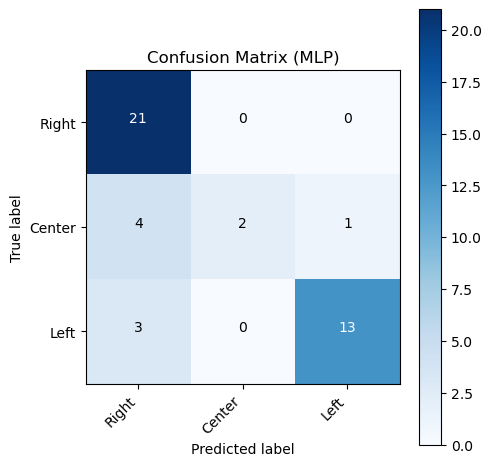

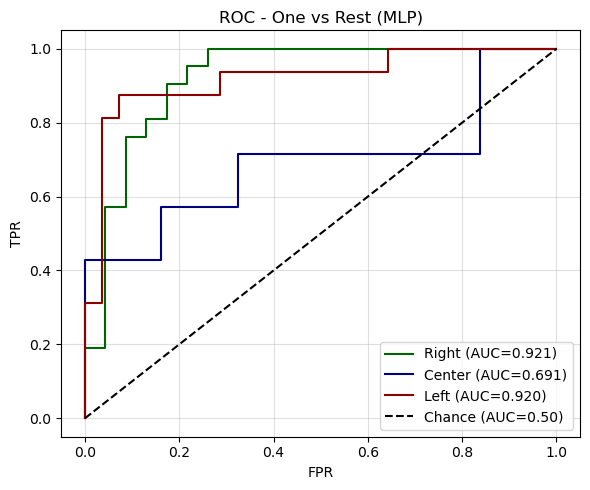

Macro AP: 0.7848 | Micro AP: 0.8318


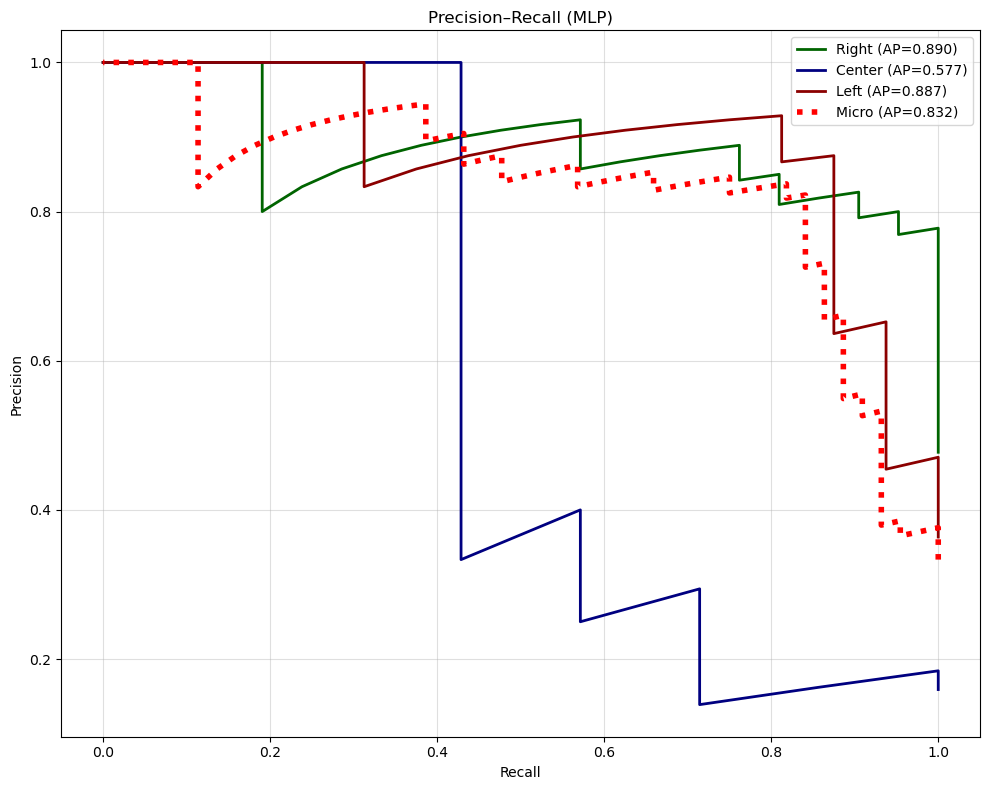

⚠️ Normalización 'nan' no reconocida. Usando datos sin normalizar.

--- Evaluación (TRANSFORMER) ---
Acc (from CM): 0.7500 | Correct: 33 | Incorrect: 11


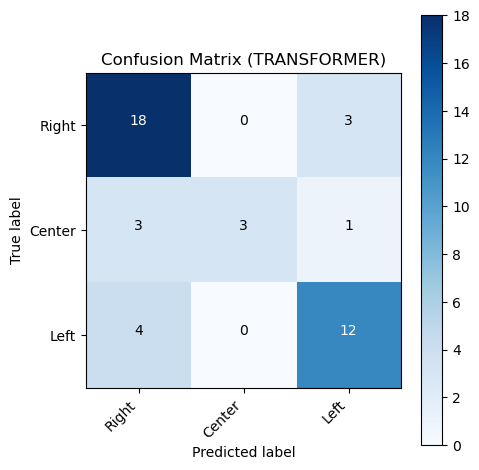

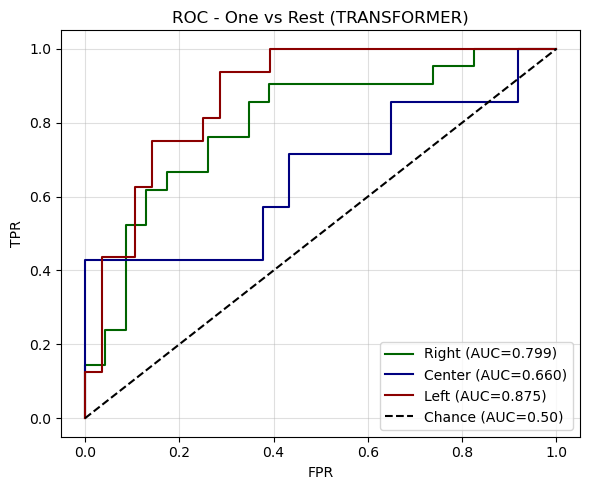

Macro AP: 0.7007 | Micro AP: 0.7400


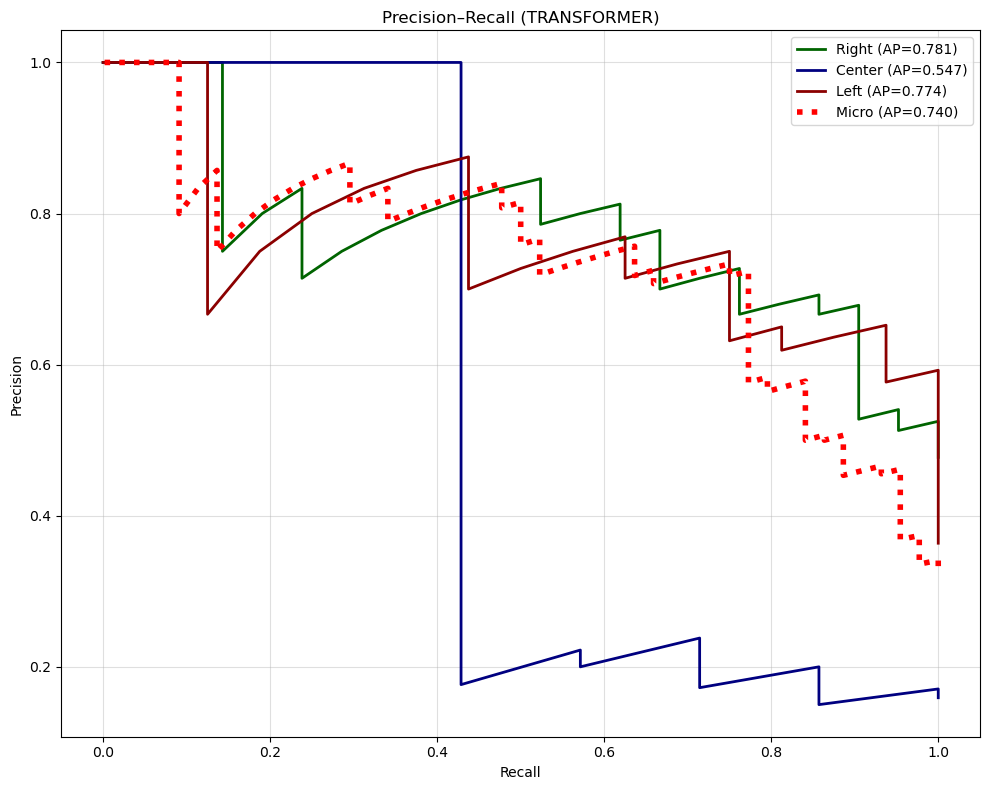

In [8]:
import os
import json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from src.mlp.prepare_data import prepare_mlp_data
from src.mlp.model import FlexibleMLP

from src.lstm.prepare_data import prepare_lstm_data, collate_sequences
from src.lstm.model import FlexibleLSTM

from src.tcn.prepare_data import prepare_tcn_data, collate_sequences
from src.tcn.model import FlexibleTCN

from src.transformer.prepare_data import prepare_transformer_data, collate_transformer
from src.transformer.model import FlexibleTransformer



DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEST_SIZE = 0.10

CLASS_NAMES = ["Right", "Center", "Left"]

SAVE_FIGS = True
FIG_DIR = "figures/Final_evaluation"
DPI = 300

# Matriz de confusión (colormap)
CM_CMAP = "Blues" 

# Colores para ROC y PR por clase (si falta alguno, matplotlib elige por defecto)
ROC_CLASS_COLORS = {"Right": "darkgreen", "Center": "navy", "Left": "darkred"}
PR_CLASS_COLORS  = {"Right": "darkgreen", "Center": "navy", "Left": "darkred"}

ROC_CHANCE_COLOR = "black"
PR_MICRO_COLOR   = "red"



def load_checkpoint(model_path: str):
    ckpt = torch.load(model_path, map_location="cpu")

    # Caso A
    if isinstance(ckpt, dict):
        # intenta encontrar config
        config = ckpt.get("config", None) or ckpt.get("cfg", None) or ckpt.get("cfg_json", None)

        # tu save_model usa 'model_state'
        state = (
            ckpt.get("model_state", None) or
            ckpt.get("model_state_dict", None) or
            ckpt.get("state_dict", None)
        )

        # cfg_json puede venir como string JSON
        if isinstance(config, str):
            try:
                config = json.loads(config)
            except Exception:
                # si era string pero no JSON válido, lo dejamos tal cual
                pass

        # Si no hay state explícito, puede que el dict entero sea el state_dict
        if state is None:
            # heurística: si parece un state_dict (muchos tensores como values)
            tensor_vals = [v for v in ckpt.values() if torch.is_tensor(v)]
            if len(tensor_vals) > 5:
                state = ckpt

        return config, state

    # Caso B
    if hasattr(ckpt, "keys"):
        return None, ckpt

    raise ValueError(f"Formato de checkpoint no soportado: {type(ckpt)}")



# RESOLVER EMBEDDING CSV
def resolve_embedding_csv_path(config: dict, base_dir=".") -> str:
    # prioridad: embedding_relpath > target_embedding
    emb_ref = config.get("embedding_relpath", None) or config.get("target_embedding", None)
    if emb_ref is None:
        raise ValueError("La config no incluye 'embedding_relpath' ni 'target_embedding'.")

    emb_ref = str(emb_ref).replace("\\", "/").strip()

    # si ya es ruta válida
    p1 = os.path.join(base_dir, emb_ref)
    if os.path.exists(p1):
        return p1

    # si solo viene nombre de archivo, buscar en carpetas conocidas
    search_roots = [
        "Gait_Embeddings_good",
        "Gait_Embeddings_Combined",
        "Gait_Embeddings_TopSteps",
        "Gait_Embeddings_WorstSteps",
    ]
    for root in search_roots:
        cand = os.path.join(base_dir, root, os.path.basename(emb_ref))
        if os.path.exists(cand):
            return cand

    raise FileNotFoundError(f"No pude localizar el embedding CSV: {emb_ref}")



# BUILD TEST LOADER A PARTIR DE config + split_seed
def build_test_loader_from_config(arch: str, df_emb: pd.DataFrame, config: dict):
    arch = arch.upper()

    split_seed = config.get("split_seed", None)
    if split_seed is None or (isinstance(split_seed, float) and np.isnan(split_seed)):
        raise ValueError("La config no tiene 'split_seed'.")
    split_seed = int(split_seed)

    if arch == "MLP":
        pooling = config["pooling"]
        norm = config["norm"]
        use_pca = bool(config.get("use_pca", False))
        pca_frac = config.get("pca_frac", None)
        if isinstance(pca_frac, str) and pca_frac.lower() in ["none", "nan", ""]:
            pca_frac = None

        tr_ds, te_ds, tr_ids, te_ids = prepare_mlp_data(
            df_emb,
            pooling=pooling,
            norm=norm,
            test_size=TEST_SIZE,
            use_pca=use_pca,
            pca_frac=pca_frac,
            seed=split_seed,
            return_preproc=False
        )
        te_loader = DataLoader(te_ds, batch_size=int(config["batch_size"]), shuffle=False)
        input_dim = tr_ds[0][0].shape[0]
        return te_loader, input_dim

    elif arch == "LSTM":
        tr_list, te_list, tr_ids, te_ids = prepare_lstm_data(
            df_emb,
            norm=config["norm"],
            test_size=TEST_SIZE,
            seed=split_seed,
            return_preproc=False
        )
        te_loader = DataLoader(
            te_list,
            batch_size=int(config["batch_size"]),
            shuffle=False,
            collate_fn=collate_sequences
        )
        input_dim = int(df_emb.filter(like="feat_").shape[1])
        return te_loader, input_dim

    elif arch == "TCN":
        tr_list, te_list, tr_ids, te_ids = prepare_tcn_data(
            df_emb,
            norm=config["norm"],
            test_size=TEST_SIZE,
            seed=split_seed,
            return_preproc=False
        )
        te_loader = DataLoader(
            te_list,
            batch_size=int(config["batch_size"]),
            shuffle=False,
            collate_fn=collate_sequences
        )
        input_dim = int(df_emb.filter(like="feat_").shape[1])
        return te_loader, input_dim

    elif arch == "TRANSFORMER":
        tr_list, te_list, tr_ids, te_ids = prepare_transformer_data(
            df_emb,
            norm=config["norm"],
            test_size=TEST_SIZE,
            seed=split_seed,
            return_preproc=False
        )
        te_loader = DataLoader(
            te_list,
            batch_size=int(config["batch_size"]),
            shuffle=False,
            collate_fn=collate_transformer
        )
        input_dim = int(df_emb.filter(like="feat_").shape[1])
        max_seq_len = max(len(s[0]) for s in tr_list) if len(tr_list) > 0 else 128
        return te_loader, (input_dim, max_seq_len)

    else:
        raise ValueError(f"Arquitectura no soportada: {arch}")



# INSTANCIA MODEL DESDE CONFIG 
def build_model_from_config(arch: str, input_info, config: dict):
    arch = arch.upper()

    if arch == "MLP":
        input_dim = int(input_info)
        model = FlexibleMLP(
            input_dim=input_dim,
            hidden_layers=config["hidden_layers"],
            activation=config["activation"],
            dropout=float(config["dropout_rate"]),
            normalization_layers=config.get("norm_layers", []),
            dropout_layers=config.get("dropout_layers", []),
            num_classes=3
        )
        return model

    elif arch == "LSTM":
        input_dim = int(input_info)
        model = FlexibleLSTM(
            input_dim=input_dim,
            num_layers=int(config["num_layers"]),
            layer_sizes=config["layer_sizes"],
            bidirectional=bool(config["bidirectional"]),
            dropout=float(config["dropout"]),
            dropout_layers=config.get("dropout_layers", []),
            norm_layers=config.get("norm_layers", []),
            pooling=str(config["pooling"]),
            fc_hidden=None if config.get("fc_hidden", None) in [None, "None", "nan"] else int(config["fc_hidden"]),
            activation=str(config["activation"]),
            norm_post_lstm=bool(config["norm_post_lstm"]),
            native_mode=bool(config["native_mode"]),
            num_classes=3
        )
        return model

    elif arch == "TCN":
        input_dim = int(input_info)
        model = FlexibleTCN(
            input_dim=input_dim,
            channels=config["channels"],
            kernel_size=int(config["kernel_size"]),
            dilations=config.get("dilations", None),
            convs_per_block=int(config["convs_per_block"]),
            dropout=config.get("dropout", 0.0),
            activation=str(config["activation"]),
            use_weight_norm=bool(config.get("use_weight_norm", False)),
            wn_on_skip=bool(config.get("wn_on_skip", False)),
            ln_block_end=config.get("ln_block_end", False),
            pooling=str(config["pooling"]),
            fc_hidden=None if config.get("fc_hidden", None) in [None, "None", "nan"] else int(config["fc_hidden"]),
            num_classes=3
        )
        return model

    elif arch == "TRANSFORMER":
        input_dim, max_seq_len = input_info
        pooling = str(config["pooling"])
        use_cls = bool(config.get("use_cls_token", (pooling.lower() == "cls")))

        model = FlexibleTransformer(
            input_dim=int(input_dim),
            model_dim=config["model_dims"],
            num_heads=int(config["num_heads"]),
            num_layers=int(config["num_layers"]),
            dim_feedforward=int(config["dim_feedforward"]),
            dropout=float(config["dropout"]),
            activation=str(config["activation"]),
            norm_type=str(config["norm_type"]),
            pos_encoding=str(config["pos_encoding"]),
            use_cls_token=use_cls,
            pooling=pooling,
            num_classes=3,
            max_seq_len=int(max_seq_len)
        )
        return model

    else:
        raise ValueError(f"Arquitectura no soportada: {arch}")



# EVALUADOR
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import torch.nn.functional as F

def get_model_predictions(model, dataloader, device, model_type: str):
    model.eval()
    all_labels, all_scores = [], []
    model_type = model_type.lower()

    with torch.no_grad():
        for batch in dataloader:
            if model_type in ['lstm', 'tcn', 'transformer']:
                inputs, lengths, labels = batch
                inputs, lengths = inputs.to(device), lengths.to(device)
                outputs = model(inputs, lengths)
            elif model_type == 'mlp':
                inputs, labels = batch
                inputs = inputs.to(device)
                outputs = model(inputs)
            else:
                raise ValueError(f"Tipo de modelo no reconocido: '{model_type}'")

            scores = torch.softmax(outputs, dim=1)
            all_labels.append(labels.cpu().numpy())
            all_scores.append(scores.cpu().numpy())

    if not all_labels:
        return np.array([]), np.array([]), np.array([])

    y_true = np.concatenate(all_labels)
    y_score = np.concatenate(all_scores)
    y_pred = np.argmax(y_score, axis=1)
    return y_true, y_pred, y_score

def evaluate_model(model, dataloader, device, class_names, model_type: str, title_tag: str = ""):
    tag = f"{title_tag}{model_type.upper()}".strip()
    safe_tag = tag.replace(" ", "_").replace("/", "-").replace("\\", "-")

    print(f"\n--- Evaluación ({tag}) ---")

    y_true, y_pred, y_score = get_model_predictions(model, dataloader, device, model_type)
    if y_true.size == 0:
        print("⚠️ No hay datos en el dataloader para evaluar.")
        return

    num_classes = len(class_names)

    if SAVE_FIGS:
        os.makedirs(FIG_DIR, exist_ok=True)


    # 1) Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
    total = cm.sum()
    correct = np.diag(cm).sum()
    acc = correct / total if total > 0 else 0.0
    print(f"Acc (from CM): {acc:.4f} | Correct: {correct} | Incorrect: {total-correct}")

    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=CM_CMAP)   
    ax.set_title(f"Confusion Matrix ({tag})")
    fig.colorbar(im, ax=ax)

    ticks = np.arange(len(class_names))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    thresh = cm.max() / 2. if cm.size else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center",
                    color="white" if cm[i, j] > thresh else "black")

    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    fig.tight_layout()

    if SAVE_FIGS:
        fig.savefig(os.path.join(FIG_DIR, f"{safe_tag}_confusion.png"), dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close(fig)


    # 2) ROC (OvR)
    y_true_bin = label_binarize(y_true, classes=range(num_classes))
    fig, ax = plt.subplots(figsize=(6, 5))

    for i in range(num_classes):
        if i < y_true_bin.shape[1]:
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)

            cls_name = class_names[i]
            cls_color = ROC_CLASS_COLORS.get(cls_name, None)

            ax.plot(fpr, tpr,
                    label=f'{cls_name} (AUC={roc_auc:.3f})',
                    color=cls_color) 

    ax.plot([0, 1], [0, 1], linestyle='--', label="Chance (AUC=0.50)", color=ROC_CHANCE_COLOR)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title(f"ROC - One vs Rest ({tag})")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.4)
    fig.tight_layout()

    if SAVE_FIGS:
        fig.savefig(os.path.join(FIG_DIR, f"{safe_tag}_roc.png"), dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close(fig)


    # 3) Precision–Recall
    fig, ax = plt.subplots(figsize=(10, 8))

    ap = {}
    for i in range(num_classes):
        if i < y_true_bin.shape[1]:
            prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
            ap[i] = average_precision_score(y_true_bin[:, i], y_score[:, i])

            cls_name = class_names[i]
            cls_color = PR_CLASS_COLORS.get(cls_name, None)

            ax.plot(rec, prec,
                    lw=2,
                    label=f"{cls_name} (AP={ap[i]:.3f})",
                    color=cls_color)

    prec_micro, rec_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_score.ravel())
    ap_micro = average_precision_score(y_true_bin, y_score, average="micro")

    ax.plot(rec_micro, prec_micro,
            linestyle=":",
            linewidth=4,
            label=f"Micro (AP={ap_micro:.3f})",
            color=PR_MICRO_COLOR) 

    macro_ap = float(np.mean([ap[i] for i in ap])) if ap else 0.0
    print(f"Macro AP: {macro_ap:.4f} | Micro AP: {ap_micro:.4f}")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Precision–Recall ({tag})")
    ax.legend(loc="best")
    ax.grid(alpha=0.4)
    fig.tight_layout()

    if SAVE_FIGS:
        fig.savefig(os.path.join(FIG_DIR, f"{safe_tag}_pr.png"), dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close(fig)



# EVALUAR VARIOS .PTH (reconstruyendo split por split_seed)
def evaluate_saved_models(model_specs, base_dir="."):
    """
    model_specs: lista de dicts:
      [
        {"arch": "TCN", "path": "saved_models/.../tcn_xxx.pth"},
        {"arch": "MLP", "path": "saved_models/.../mlp_xxx.pth"},
      ]
    """
    for spec in model_specs:
        arch = spec["arch"]
        model_path = spec["path"]

        cfg, state = load_checkpoint(model_path)
        if cfg is None or state is None:
            raise ValueError(
                f"No pude extraer config/model_state de {model_path}. "
                f"Asegúrate de guardar 'config' y 'model_state' dentro del .pth."
            )


        emb_csv = resolve_embedding_csv_path(cfg, base_dir=base_dir)
        df_emb = pd.read_csv(emb_csv, low_memory=False)


        test_loader, input_info = build_test_loader_from_config(arch, df_emb, cfg)

        model = build_model_from_config(arch, input_info, cfg).to(DEVICE)
        model.load_state_dict(state)
        model.eval()

        evaluate_model(
            model=model,
            dataloader=test_loader,
            device=DEVICE,
            class_names=CLASS_NAMES,
            model_type=arch.lower(),
            title_tag=""
        )



models = ["MLP", "LSTM", "TCN", "Transformer"]
WINNERS = [
    {"arch": arch, "path": winner_ckpts[arch]["ckpt_path"]}
    for arch in models
    if arch in winner_ckpts
]

print("\nWINNERS que se van a evaluar:")
for w in WINNERS:
    print(" -", w["arch"], "->", w["path"])

evaluate_saved_models(WINNERS, base_dir=".")